In [2]:
import kagglehub
from fontTools.voltLib import voltToFea
from pandas.core.window.rolling import RollingAndExpandingMixin

path=kagglehub.dataset_download("arnabbiswas1/microsoft-azure-predictive-maintenance")
print(path)

D:\pythoninphora\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\Gaganpreet kour\.cache\kagglehub\datasets\arnabbiswas1\microsoft-azure-predictive-maintenance\versions\3


In [3]:
import pandas as pd
import os
print(os.listdir(path))

#after loading dataset im reading it
telemetry=pd.read_csv(os.path.join(path,"PdM_telemetry.csv"))
errors=pd.read_csv(os.path.join(path,"PdM_errors.csv"))
failures=pd.read_csv(os.path.join(path,"PdM_failures.csv"))
maint=pd.read_csv(os.path.join(path,"PdM_maint.csv"))
machines=pd.read_csv(os.path.join(path,"PdM_machines.csv"))

print(telemetry.head())
print(errors.head())
print(failures.head())
print(maint.head())
print(machines.head())

#cgeck shapes --> because i wanna inspect my data first
print(telemetry.shape)
print(errors.shape)
print(maint.shape)
print(machines.shape)
print(failures.shape)

#covert dates
telemetry["datetime"]=pd.to_datetime(telemetry["datetime"])
errors["datetime"]=pd.to_datetime(errors["datetime"])
maint["datetime"]=pd.to_datetime(maint["datetime"])
failures["datetime"]=pd.to_datetime(failures["datetime"])

#merge machine info , error , maintenance , failures
master=telemetry.merge(
    machines,
    on="machineID",
    how="left"
)

master=master.merge(
    errors,
    on=["machineID","datetime"],
    how="left"
)

master=master.merge(
    maint,
    on=["machineID","datetime"],
    how="left"
)

master=master.merge(
    failures,
    on=["machineID","datetime"],
    how="left"
)

print(master.head())


['PdM_errors.csv', 'PdM_failures.csv', 'PdM_machines.csv', 'PdM_maint.csv', 'PdM_telemetry.csv']
              datetime  machineID        volt      rotate    pressure  \
0  2015-01-01 06:00:00          1  176.217853  418.504078  113.077935   
1  2015-01-01 07:00:00          1  162.879223  402.747490   95.460525   
2  2015-01-01 08:00:00          1  170.989902  527.349825   75.237905   
3  2015-01-01 09:00:00          1  162.462833  346.149335  109.248561   
4  2015-01-01 10:00:00          1  157.610021  435.376873  111.886648   

   vibration  
0  45.087686  
1  43.413973  
2  34.178847  
3  41.122144  
4  25.990511  
              datetime  machineID errorID
0  2015-01-03 07:00:00          1  error1
1  2015-01-03 20:00:00          1  error3
2  2015-01-04 06:00:00          1  error5
3  2015-01-10 15:00:00          1  error4
4  2015-01-22 10:00:00          1  error4
              datetime  machineID failure
0  2015-01-05 06:00:00          1   comp4
1  2015-03-06 06:00:00          1   co

In [4]:
#understanding my dataset

print(master.shape)                 #row col
print(master.columns)               #col
print(master.info())                #miss val,non null count,data type
print(master.head())                #1st 5
print(master.describe())            #mean min max standrd deviation
print(master.tail())                #last 5


#DATA CLEANING

#missing value
print(master.isnull().sum())        #nan
master["errorID"]=master["errorID"].fillna("no error")
master["comp"]=master["comp"].fillna("no maintenance")
master["failure"]=master["failure"].fillna("no failure")


print(master.duplicated().sum())            #duplicate row
print(master.dtypes)                        #data type

# #FEATURE ENGINEERING TIME FEATURES
# print(master["datetime"])
# master["year"]=master["datetime"].dt.year
# master["month"]=master["datetime"].dt.month
# master["day"]=master["datetime"].dt.day
# master["hour"]=master["datetime"].dt.hour
# master["dayofweek"]=master["datetime"].dt.dayofweek


#SAVING MY CLEANED DATASET
master.to_csv("master_cleaned.csv",index=False)
master=pd.read_csv("master_cleaned.csv")



(877209, 11)
Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration',
       'model', 'age', 'errorID', 'comp', 'failure'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 877209 entries, 0 to 877208
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   877209 non-null  datetime64[us]
 1   machineID  877209 non-null  int64         
 2   volt       877209 non-null  float64       
 3   rotate     877209 non-null  float64       
 4   pressure   877209 non-null  float64       
 5   vibration  877209 non-null  float64       
 6   model      877209 non-null  str           
 7   age        877209 non-null  int64         
 8   errorID    3924 non-null    str           
 9   comp       2968 non-null    str           
 10  failure    1122 non-null    str           
dtypes: datetime64[us](1), float64(4), int64(2), str(4)
memory usage: 79.1 MB
None
             datetime  machineID

(877209, 11)
<class 'pandas.DataFrame'>
RangeIndex: 877209 entries, 0 to 877208
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   877209 non-null  str    
 1   machineID  877209 non-null  int64  
 2   volt       877209 non-null  float64
 3   rotate     877209 non-null  float64
 4   pressure   877209 non-null  float64
 5   vibration  877209 non-null  float64
 6   model      877209 non-null  str    
 7   age        877209 non-null  int64  
 8   errorID    877209 non-null  str    
 9   comp       877209 non-null  str    
 10  failure    877209 non-null  str    
dtypes: float64(4), int64(2), str(5)
memory usage: 121.3 MB
None
           machineID           volt         rotate       pressure  \
count  877209.000000  877209.000000  877209.000000  877209.000000   
mean       50.498446     170.780942     446.570735     100.861433   
std        28.866697      15.511268      52.698963      11.052195   
min         1

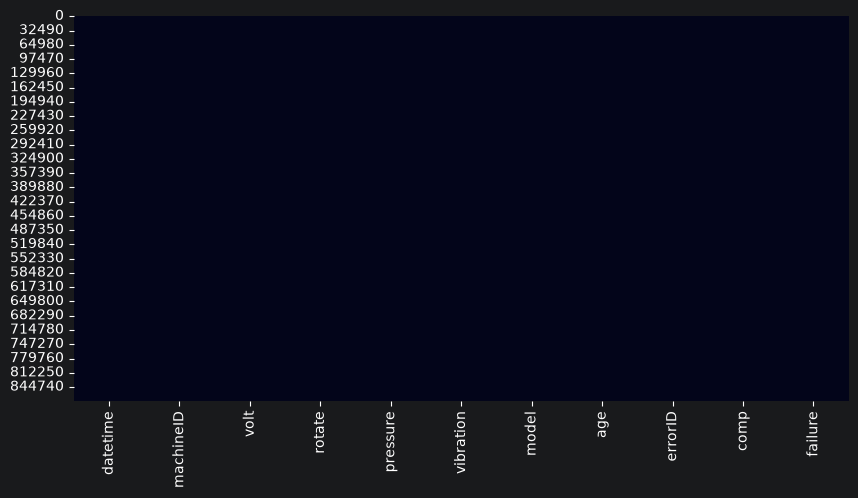

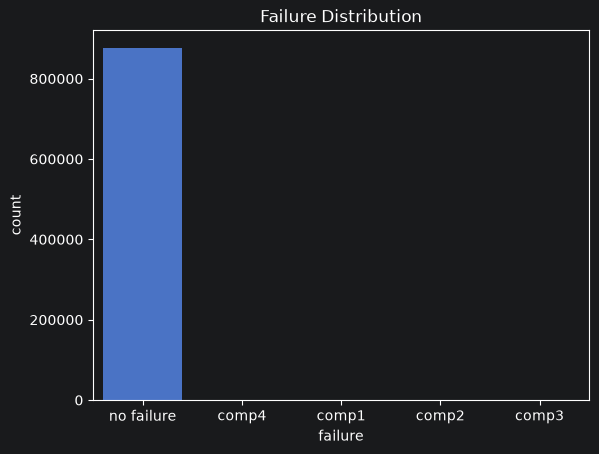

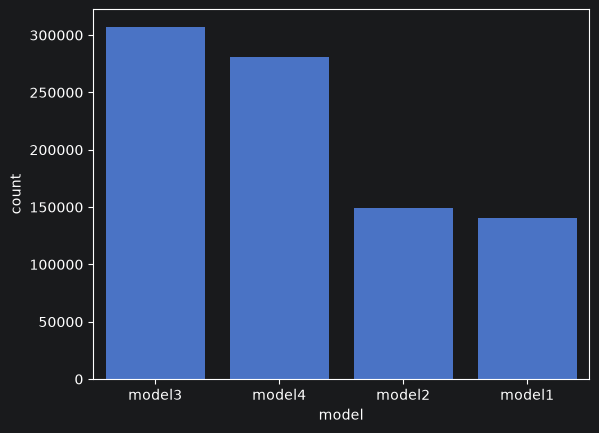

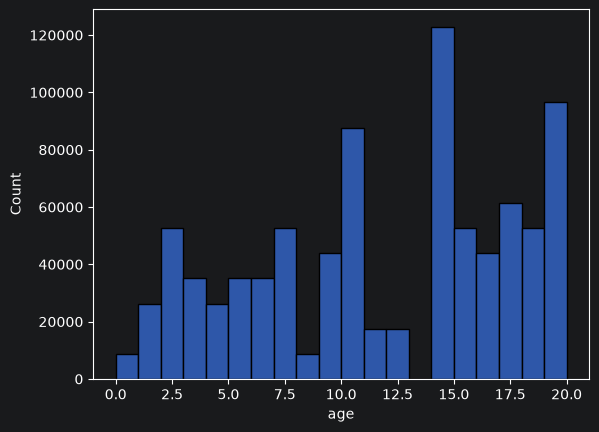

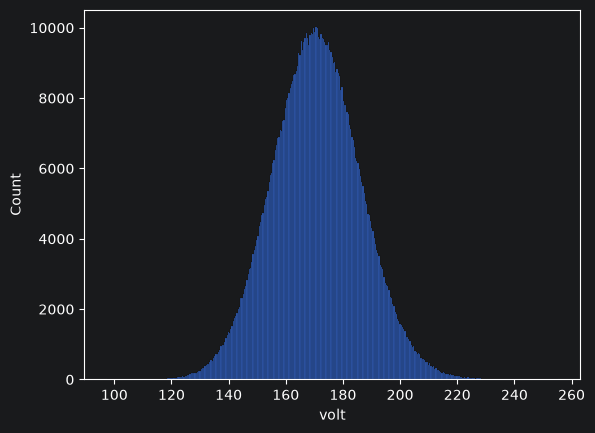

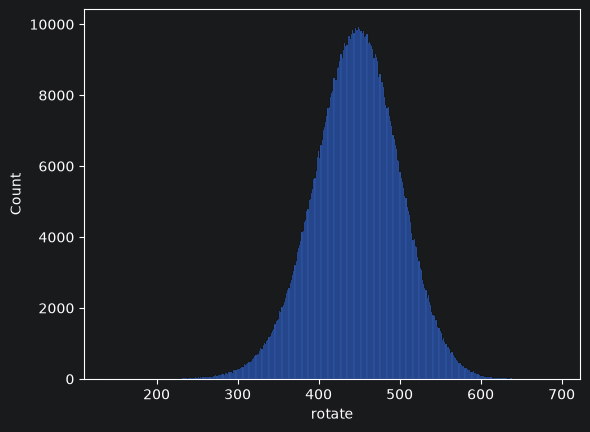

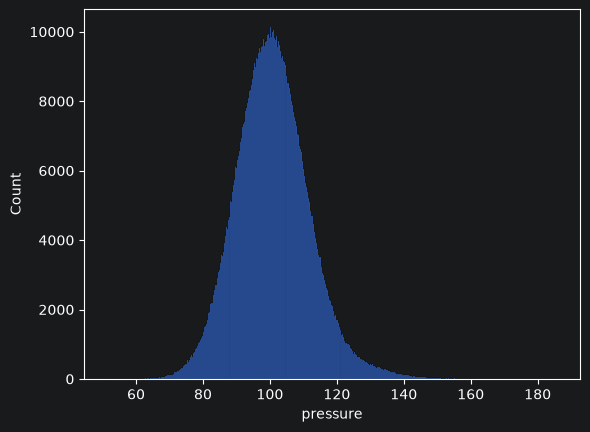

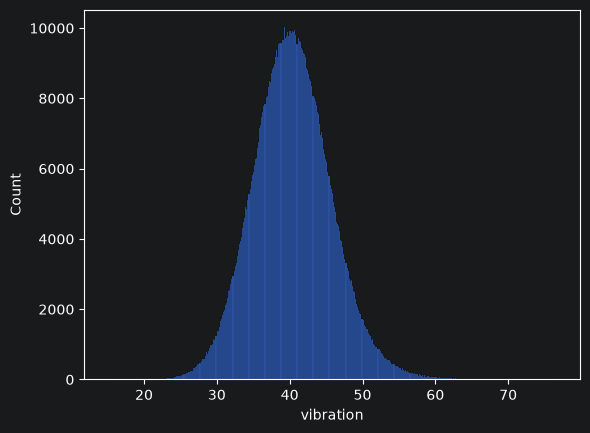

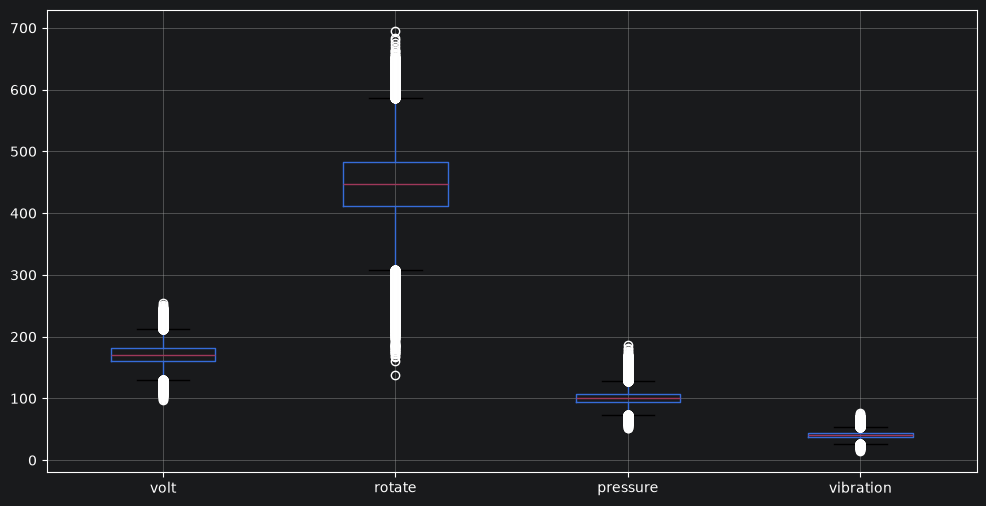

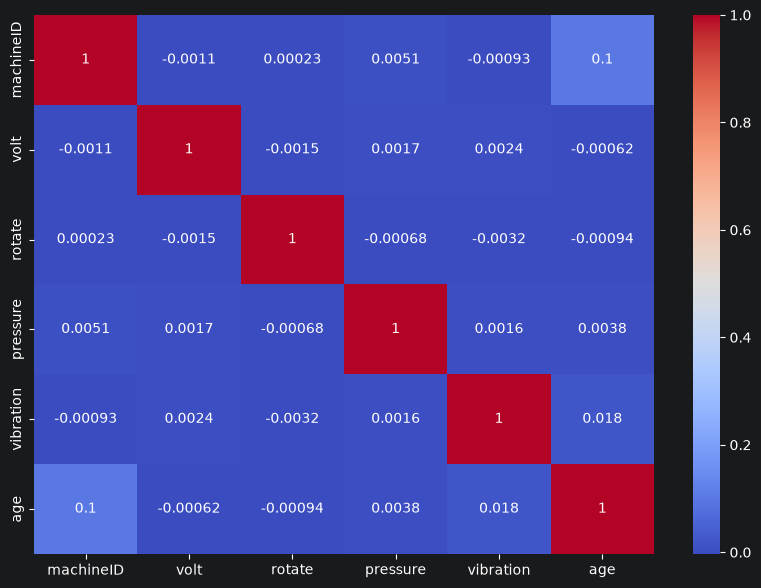

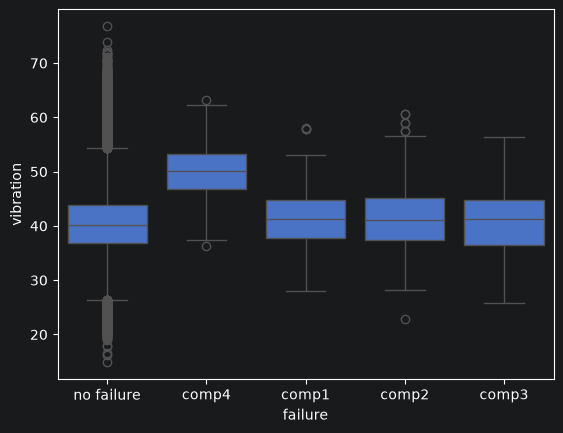

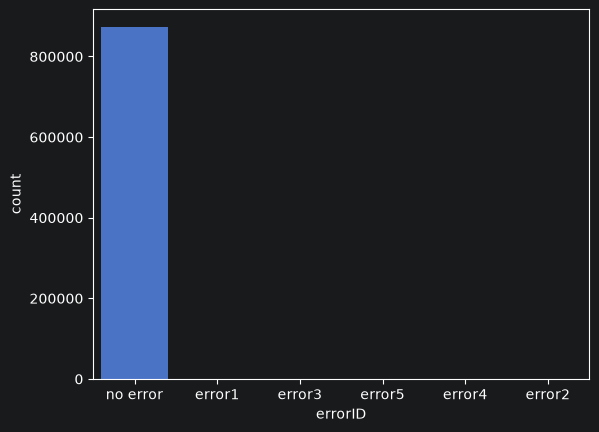

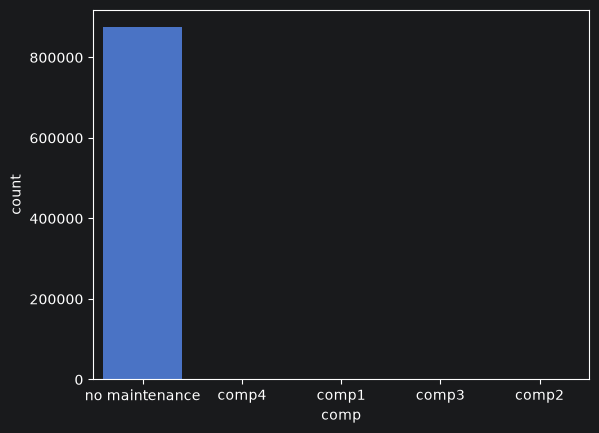

['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'model', 'age', 'errorID', 'comp', 'failure']


In [5]:
#EDA (EXPLORATORY DATA ANALYSIS)

#dataset overview
print(master.shape)
print(master.info())
print(master.describe())
print(master.head())

#visualize missing value
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.heatmap(master.isnull(),cbar=False)
plt.show()

#check targeted value
master["failure"].value_counts()

sns.countplot(data=master,x="failure")
plt.title("Failure Distribution")
plt.show()

#machine model analysis
master["model"].value_counts()

sns.countplot(data=master,x="model")
plt.show()

#machine age analysis
master["age"].describe()
sns.histplot(master["age"],bins=20)
plt.show()

#sensor analysis --> here we study each sensor individually

sns.histplot(master["volt"])
plt.show()
sns.histplot(master["rotate"])
plt.show()
sns.histplot(master["pressure"])
plt.show()
sns.histplot(master["vibration"])
plt.show()

#boxplot(outliers)
plt.figure(figsize=(12,6))
master[["volt","rotate","pressure","vibration"]].boxplot()
plt.show()

#correlation analysis
corr=master.select_dtypes(include="number").corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

#failure vs sensors
sns.boxplot(data=master,
            x="failure",
            y="vibration")
plt.show()

#error analysis
master["errorID"].value_counts()
sns.countplot(
    data=master,
    x="errorID"
)
plt.show()

#maintenance analysis
master["comp"].value_counts()
sns.countplot(
    data=master,
    x="comp"
)
plt.show()

# #time analysis
# # master["datetime"]=pd.to_datetime(master["datetime"])
# # master["month"]=master["datetime"].dt.month
# sns.countplot(
#     data=master,
#     x="datetime"
# )
# plt.show()
print(master.columns.tolist())

In [6]:
#FEATURE ENGINEERING

#1.create age group
master["age_group"]=pd.cut(
    master["age"],
    bins=[0,5,10,20],
    labels=["New","Medium","Old"]
)
print(master[["age","age_group"]].head())

# #2.create binary error feature
master["has_error"]=(master["errorID"]!="no error").astype(int)
print(master["has_error"])

# #3.maintenance feature
# master["maintenance_done"]=(master["comp"]!="No Maintenance").astype(int)
# master["maintenance_done"]

#rolling average
master=master.sort_values(["machineID","datetime"])
master["vibration_roll3"]=(master.groupby("machineID")["vibration"].transform(lambda x:x.rolling(window=3,min_periods=1).mean())
)
print(master["vibration_roll3"])

#previous error count
master["error_count"]=(
    master["has_error"].groupby(master["machineID"])
    .cumsum()
)
print(master["error_count"])


   age age_group
0   18       Old
1   18       Old
2   18       Old
3   18       Old
4   18       Old
0         0
1         0
2         0
3         0
4         0
         ..
877204    0
877205    0
877206    0
877207    0
877208    0
Name: has_error, Length: 877209, dtype: int64
0         45.087686
1         44.250829
2         40.893502
3         39.571655
4         33.763834
            ...    
877204    47.481232
877205    43.425922
877206    44.736524
877207    42.757630
877208    43.665022
Name: vibration_roll3, Length: 877209, dtype: float64
0          0
1          0
2          0
3          0
4          0
          ..
877204    31
877205    31
877206    31
877207    31
877208    31
Name: error_count, Length: 877209, dtype: int64


In [11]:
#DATA PREPROCESSING
#1.target variable
master["failure"].value_counts(dropna=False)

master["failure_binary"]=(master["failure"]!= "no failure").astype(int)
print(master[["failure","failure_binary"]].head(10))
print(master["failure_binary"].value_counts())

#2.create input feature x and target y
x=master.drop(
    columns=[
        "failure",
        "failure_binary",
        "datetime",
        "machineID",
    ]
)
y=master["failure_binary"]
print(x.columns)
print(x.shape)
x=x.drop(columns=["has_error"])

#3.separate numerical(num) and categorical(cat) values
num_cols=[
    "volt",
    "rotate",
    "pressure",
    "vibration",
    "age",
    "vibration_roll3",
    "error_count"
]

cat_cols=[
    "model",
    "errorID",
    "comp",
    "age_group"
]
print(x[num_cols].dtypes)
print(x[cat_cols].dtypes)
print(x[num_cols].head())
print(x[cat_cols].head())

#4. split database
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("shape of training data is :",x_train.shape)
print("shape of testing data is:",x_test.shape)

#5.encoding categorical features
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(handle_unknown="ignore")

x_train_cat=encoder.fit_transform(x_train[cat_cols])
x_test_cat=encoder.transform(x_test[cat_cols])

print(x_train_cat.shape)
print(encoder.get_feature_names_out(cat_cols))

#6.scale numerical features
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_num=scaler.fit_transform(x_train[num_cols])
x_test_num=scaler.transform(x_test[num_cols])
print(x_train_num)      #all values are now be centered around 0with standard deviation of 1

#7.combine everything using columntransformer
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),num_cols),
        ("cat",OneHotEncoder(handle_unknown="ignore"),cat_cols)
    ]
)

x_train_processed=preprocessor.fit_transform(x_train)
x_test_processed=preprocessor.transform(x_test)
print(x_train_processed)

#8.create a pipeline --> instead of remembering to preprocess first and then train , we connect everything into one workflow
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(random_state=42))
])
pipeline.fit(x_train,y_train)
y_pred=pipeline.predict(x_test)
y_pred

      failure  failure_binary
0  no failure               0
1  no failure               0
2  no failure               0
3  no failure               0
4  no failure               0
5  no failure               0
6  no failure               0
7  no failure               0
8  no failure               0
9  no failure               0
failure_binary
0    876087
1      1122
Name: count, dtype: int64
Index(['volt', 'rotate', 'pressure', 'vibration', 'model', 'age', 'errorID',
       'comp', 'age_group', 'has_error', 'vibration_roll3', 'error_count'],
      dtype='str')
(877209, 12)
volt               float64
rotate             float64
pressure           float64
vibration          float64
age                  int64
vibration_roll3    float64
error_count          int64
dtype: object
model             str
errorID           str
comp              str
age_group    category
dtype: object
         volt      rotate    pressure  vibration  age  vibration_roll3  \
0  176.217853  418.504078  113.077935  45

array([0, 0, 0, ..., 0, 0, 0], shape=(175442,))

In [8]:
#MODEL BUILDING
#import the model
from sklearn.ensemble import RandomForestClassifier

#create model
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

#train the model
rf.fit(x_train_processed,y_train)

#make predictions
y_pred=rf.predict(x_test_processed)        #it predict 0-no failure and 1 - failure

#predict probabilities
y_prob= rf.predict_proba(x_test_processed)

failure_probability = y_prob[:,1]



[0 0 0 ... 0 0 0]
[[175187     31]
 [    86    138]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    175218
           1       0.82      0.62      0.70       224

    accuracy                           1.00    175442
   macro avg       0.91      0.81      0.85    175442
weighted avg       1.00      1.00      1.00    175442

Accuracy of your model is :  0.999333112937609
Precision score of your model is : 0.8165680473372781
Recall score of your model is :  0.6160714285714286
F1_score of your model is :  0.7022900763358778
[0. 0. 0. ... 0. 0. 0.]
0.9885527039377885


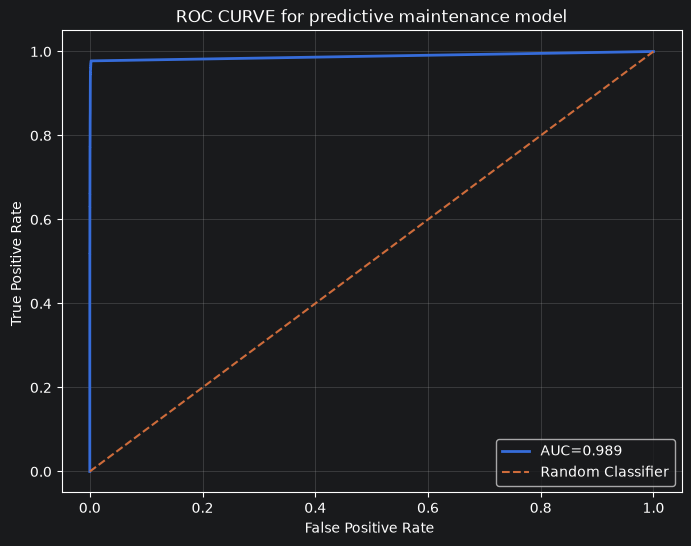

26
                     feature  importance
21  cat__comp_no maintenance    0.215368
1                num__rotate    0.098175
5       num__vibration_roll3    0.088398
2              num__pressure    0.087667
0                  num__volt    0.081983
18           cat__comp_comp2    0.071396
3             num__vibration    0.069424
20           cat__comp_comp4    0.053729
6           num__error_count    0.047859
17           cat__comp_comp1    0.041902
4                   num__age    0.041865
19           cat__comp_comp3    0.035915
7          cat__model_model1    0.012330
8          cat__model_model2    0.010461
24        cat__age_group_Old    0.010007
                     feature    importance
21  cat__comp_no maintenance  2.153681e-01
1                num__rotate  9.817491e-02
5       num__vibration_roll3  8.839755e-02
2              num__pressure  8.766722e-02
0                  num__volt  8.198298e-02
18           cat__comp_comp2  7.139604e-02
3             num__vibration  6.942386e-

In [9]:
#MODEL EVALUATION
#1.make predictions
y_pred=rf.predict(x_test_processed)
print(y_pred)

#2.confusion  matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

#3.classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

#4.accuracy
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy of your model is : ",accuracy)

#5.precision
from sklearn.metrics import precision_score
precision=precision_score(y_test,y_pred)
print("Precision score of your model is :" ,precision)

#6.recall
from sklearn.metrics import recall_score
recall=recall_score(y_test,y_pred)
print("Recall score of your model is : ",recall)

#7.f1 score
from sklearn.metrics import f1_score
f1_score=f1_score(y_test,y_pred)
print("F1_score of your model is : ",f1_score)

#8.roc-auc score
y_prob=rf.predict_proba(x_test_processed)[:,1]
print(y_prob)

from sklearn.metrics import roc_auc_score,roc_curve
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
auc= roc_auc_score(y_test,y_prob)
print(auc)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,linewidth=2,label=f"AUC={auc:.3f}")

plt.plot([0,1],[0,1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate ")
plt.ylabel("True Positive Rate ")
plt.title("ROC CURVE for predictive maintenance model")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()


#9.feature importance
feature_names=preprocessor.get_feature_names_out()
print(len(feature_names))
importance =pd.DataFrame({
    "feature":feature_names,
    "importance":rf.feature_importances_
})
importance=importance.sort_values(
    by="importance",
    ascending=False

)
print(importance.head(15))

print(importance)

In [12]:
#save trained model
import joblib
joblib.dump(rf,"random_forest_model.pkl")
joblib.dump(preprocessor,"preprocessor.pkl")
import os
print(os.listdir())




['.idea', '.venv', 'file.csv', 'first.ipynb', 'main.py', 'master_cleaned.csv', 'matplotlib.ipynb', 'numpy.ipynb', 'pandas.ipynb', 'preprocessor.pkl', 'PROJECT.ipynb', 'random_forest_model.pkl', 'save', 'scikit learn.ipynb', 'supervisedlearning.ipynb', '__pycache__']
